# Segmentação de clientes com GMM

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Interpretar médias e incerteza de quatro componentes.

**Pergunta-guia:** Quais clientes têm menor probabilidade da classe atribuída?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

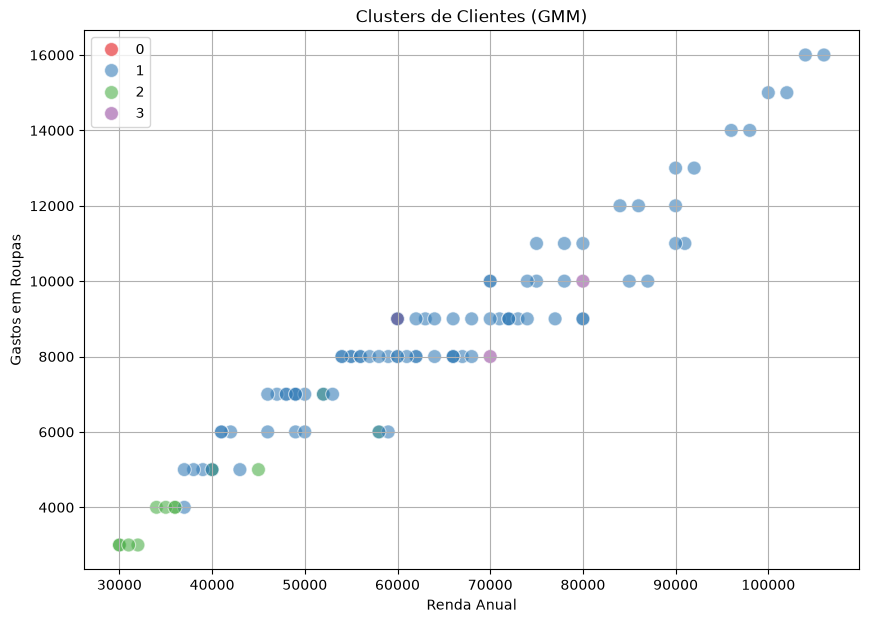

In [1]:
# parte 1
from pathlib import Path

import pandas as pd
from sklearn.preprocessing import StandardScaler


def resolve_data_path(filename: str, must_exist: bool = True) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    if must_exist:
        raise FileNotFoundError(
            f"Nao foi possivel localizar o arquivo de dados '{filename}' em {candidates}."
        )

    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    return candidates[0].resolve()


# Carregar os dados
data = pd.read_csv(resolve_data_path("14.1 - customer_data.csv"))

# Selecionar as colunas relevantes
X = data[['Renda Anual', 'Gastos em Roupas', 'Gastos em Eletrônicos', 'Gastos em Saúde']]

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# parte 2
from sklearn.mixture import GaussianMixture

# Aplicar GMM
gmm = GaussianMixture(n_components=4, random_state=0)
gmm.fit(X_scaled)
data['Cluster'] = gmm.predict(X_scaled)

# Parametros das distribuicoes gaussianas
means = gmm.means_
covariances = gmm.covariances_

# parte 3
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizacao dos clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Renda Anual', y='Gastos em Roupas', hue='Cluster', data=data, palette='Set1', s=100, alpha=0.6)
plt.title('Clusters de Clientes (GMM)')
plt.xlabel('Renda Anual')
plt.ylabel('Gastos em Roupas')
plt.legend()
plt.grid(True)
plt.show()

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
probabilidades = gmm.predict_proba(X_scaled)
print('Tamanhos dos grupos:', data['Cluster'].value_counts().sort_index().to_dict())
print('Perfis médios nas unidades originais:')
print(data.groupby('Cluster')[X.columns].mean().round(1))
print('Menor confiança da atribuição:', round(probabilidades.max(axis=1).min(), 3))
for k in range(2, 7):
    candidato = GaussianMixture(n_components=k, random_state=0).fit(X_scaled)
    print(f'componentes={k}: BIC={candidato.bic(X_scaled):.1f}')

Tamanhos dos grupos: {0: 1, 1: 83, 2: 13, 3: 3}
Perfis médios nas unidades originais:
         Renda Anual  Gastos em Roupas  Gastos em Eletrônicos  Gastos em Saúde
Cluster                                                                       
0            60000.0            9000.0                 5000.0           7000.0
1            65566.3            8771.1                 6556.6           7556.6
2            38384.6            4307.7                 1623.1           2430.8
3            70000.0            9000.0                 7000.0           6333.3
Menor confiança da atribuição: 1.0
componentes=2: BIC=-583.4
componentes=3: BIC=-1450.3
componentes=4: BIC=-1448.2
componentes=5: BIC=-1559.0
componentes=6: BIC=-1535.8


## Interpretação e limites

Um componente estatístico não deve receber um rótulo de negócio sem examinar seu perfil. `Gastos em Alimentos` é exatamente `Gastos em Roupas + 1000` neste arquivo; duplicá-lo daria peso extra à mesma informação.

## Exercício

Compare BIC para diferentes números de componentes e confronte com K-means.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.